# Requirement 2 — Multi-Campaign, Stochastic Bidding

**Setting:** N campaigns, each with an i.i.d. stochastic competing bid $m_{i,t} \sim \text{Beta}(k_i, 1)$,
shared total budget $B_{\text{total}}$, per-round budget $\rho = B_{\text{total}} / T$,
and a conflict graph $G$ that forbids bidding on conflicting campaigns simultaneously.

**Algorithm:** Combinatorial UCB-like bidder (`CombUCBLikeBidderAgent`) — extends Phase 1B
to multiple campaigns. For each feasible independent set (IS) it solves a joint LP over
per-campaign mixed strategies subject to the budget constraint, then picks the IS with the
highest UCB-optimistic objective.

**Clairvoyant:** Same LP structure with true win probabilities; best IS wins.

In [2]:
import sys, os

# Resolve repo root whether notebook is run from repo root or notebooks/
repo_root = os.path.abspath('.')
if not os.path.isdir(os.path.join(repo_root, 'src')):
    repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
    
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from src.core.multi_campaign_env import MultiCampaignEnv
from src.core.conflict_graph import ConflictGraph
from src.core.cucb_bidder import CombUCBLikeBidderAgent
from src.core.clairvoyant import win_probs_multi_campaign, clairvoyant_multi_campaign
from src.utils.parallel_runner import run_trials_parallel
from src.utils.regret import summarise_regret
from src.utils.plotting import new_figure, plot_regret, save_figure

# CombUCBLikeBidderAgent solves one LP per feasible independent set every
# round, so a full run (T=5000, 25 trials) is CPU-bound and slow if run
# sequentially. Trials are independent, so run_trials_parallel spreads them
# across worker processes instead of src.utils.runner.run_trials.
n_jobs = os.cpu_count()
print(f"Using n_jobs = {n_jobs} worker processes for trial parallelisation")

Using n_jobs = 8 worker processes for trial parallelisation


## Problem Instance

Five campaigns with two conflict edges: campaigns 0–1 conflict, campaigns 2–3 conflict.
Campaign 4 has no conflicts. The maximal independent sets therefore have size 3
(one from {0,1}, one from {2,3}, plus campaign 4).

In [3]:
# --- Problem parameters ---
N           = 5
K           = 20
T           = 15000
n_trials    = 8
master_seed = 42

values       = np.array([0.90, 0.80, 0.70, 0.85, 0.75])
n_competitors = np.array([3, 2, 4, 2, 3])   # k_i for Beta(k_i, 1)

# Shared bid grid: 0 to 1 (covers all values since max(values) = 0.9 < 1)
bid_grid = np.linspace(0.0, 1.0, K)

# Conflict graph: (0,1) and (2,3) are conflicting pairs
edges = [(0, 1), (2, 3)]
cg    = ConflictGraph(N, edges)

# Budget: rho = 0.4 per round (moderately binding constraint)
rho     = 0.40
B_total = rho * T  # = 2000.0

print(f"Campaigns   : {N}")
print(f"Bid levels  : {K}")
print(f"Horizon T   : {T}")
print(f"Trials      : {n_trials}")
print(f"rho         : {rho:.3f}   (B_total = {B_total:.0f})")
print(f"Conflict edges: {edges}")
print(f"Feasible IS count: {len(cg.all_independent_sets())}")

Campaigns   : 5
Bid levels  : 20
Horizon T   : 15000
Trials      : 8
rho         : 0.400   (B_total = 6000)
Conflict edges: [(0, 1), (2, 3)]
Feasible IS count: 17


Saved → G:\Polimi\Sem 4\OLA\Project\github\report\figures\req2_conflict_graph.png


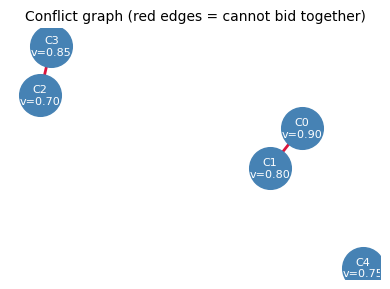

In [4]:
# Visualise the conflict graph
fig, ax = plt.subplots(figsize=(4, 3))
pos = nx.spring_layout(cg.G, seed=0)
labels = {i: f"C{i}\nv={values[i]:.2f}" for i in range(N)}
nx.draw_networkx(cg.G, pos=pos, labels=labels, ax=ax,
                 node_color="steelblue", node_size=900,
                 font_size=8, font_color="white", edge_color="crimson", width=2)
ax.set_title("Conflict graph (red edges = cannot bid together)", fontsize=10)
ax.axis("off")
plt.tight_layout()
save_figure(fig, "report/figures/req2_conflict_graph.png")

## Clairvoyant Benchmark

The clairvoyant knows the true win-probability functions $P(m_i \le b) = b^{k_i}$
and solves an LP over per-campaign mixed strategies for each feasible IS,
picking the one with the highest expected per-round utility subject to $\rho$.

In [5]:
win_probs = win_probs_multi_campaign(bid_grid, n_competitors)  # (N, K)

best_gamma, clairvoyant_reward, clairvoyant_cost = clairvoyant_multi_campaign(
    bid_grid, values, rho, win_probs, cg
)

print(f"Clairvoyant per-round reward : {clairvoyant_reward:.4f}")
print(f"Clairvoyant per-round cost   : {clairvoyant_cost:.4f}  (budget rho = {rho:.3f})")
print(f"Campaigns in best IS         : {sorted(best_gamma.keys())}")
print(f"Budget utilisation           : {clairvoyant_cost / rho * 100:.1f}%")

Clairvoyant per-round reward : 0.1989
Clairvoyant per-round cost   : 0.4000  (budget rho = 0.400)
Campaigns in best IS         : [1, 3, 4]
Budget utilisation           : 100.0%


Saved → G:\Polimi\Sem 4\OLA\Project\github\report\figures\req2_clairvoyant_bids.png


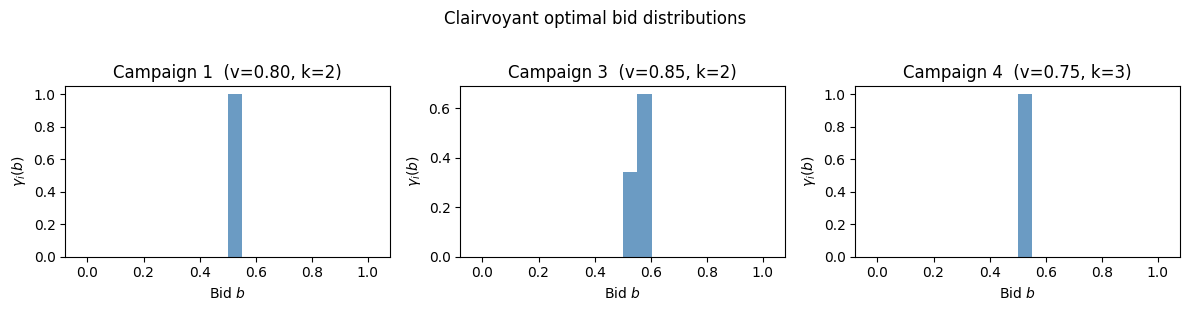

In [6]:
# Show the optimal bid distribution per selected campaign
fig, axes = plt.subplots(1, len(best_gamma), figsize=(4 * len(best_gamma), 3), sharey=False)
if len(best_gamma) == 1:
    axes = [axes]
for ax, (i, gamma_i) in zip(axes, sorted(best_gamma.items())):
    ax.bar(bid_grid, gamma_i, width=bid_grid[1] - bid_grid[0], color="steelblue", alpha=0.8)
    ax.set_title(f"Campaign {i}  (v={values[i]:.2f}, k={n_competitors[i]})")
    ax.set_xlabel("Bid $b$")
    ax.set_ylabel("$\\gamma_i(b)$")
plt.suptitle("Clairvoyant optimal bid distributions", y=1.02)
plt.tight_layout()
save_figure(fig, "report/figures/req2_clairvoyant_bids.png")

## Algorithm — CombUCBLike with Conflict Graph + Budget

Run `n_trials` independent trials and collect the regret matrix.

In [7]:
print(f"Running {n_trials} trials × {T} rounds …")
results_cg = run_trials_parallel(
    env_cls=MultiCampaignEnv,
    env_kwargs=dict(values=values, T=T, n_competitors=n_competitors),
    agent_cls=CombUCBLikeBidderAgent,
    agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg),
    T=T,
    n_trials=n_trials,
    master_seed=master_seed,
    clairvoyant_reward=clairvoyant_reward,
    n_jobs=n_jobs,
)
print("Done.")

Running 8 trials × 15000 rounds …
Done.


## Results — Cumulative Regret

Saved → G:\Polimi\Sem 4\OLA\Project\github\report\figures\req2_regret_main.png


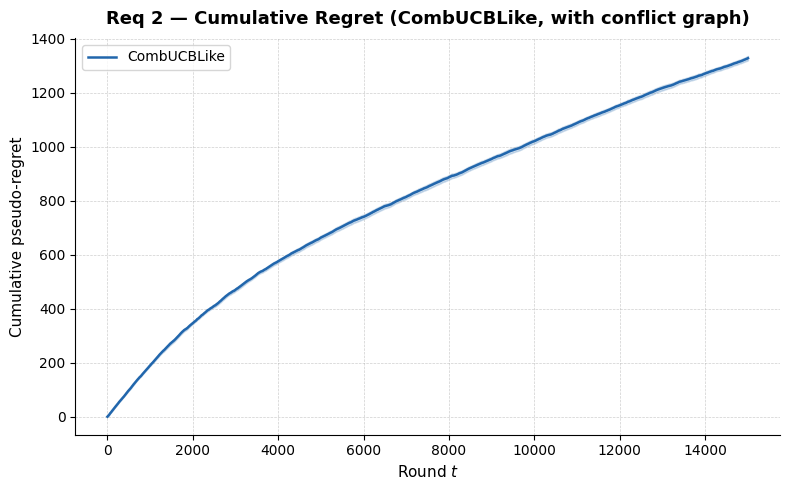

In [8]:
mean_reg_cg, std_reg_cg = summarise_regret(results_cg["regret_matrix"])
ts = np.arange(1, T + 1)

fig, ax = new_figure("Req 2 — Cumulative Regret (CombUCBLike, with conflict graph)")
plot_regret(ax, mean_reg_cg, std_reg_cg, n_trials, label="CombUCBLike")
ax.set_xlabel("Round $t$")
ax.set_ylabel("Cumulative pseudo-regret")
ax.legend()
plt.tight_layout()
save_figure(fig, "report/figures/req2_regret_main.png")

In [9]:
final_mean = mean_reg_cg[-1]
final_std  = std_reg_cg[-1]
print(f"Final cumulative regret (T={T}): {final_mean:.2f} ± {final_std:.2f}  (across {n_trials} trials)")
print(f"Average regret per round        : {final_mean / T:.5f}")

Final cumulative regret (T=15000): 1328.98 ± 23.04  (across 8 trials)
Average regret per round        : 0.08860


## Budget Consumption Over Time

Sanity check: cumulative cost must never exceed $B_{\text{total}}$.
The straight dashed line is the budget limit.

Saved → G:\Polimi\Sem 4\OLA\Project\github\report\figures\req2_budget_consumption.png
Max spend across all trials : 5929.526316  (limit: 6000.0, tolerance: +1e-06)
Mean final spend            : 5841.7697
Budget never violated in any trial.


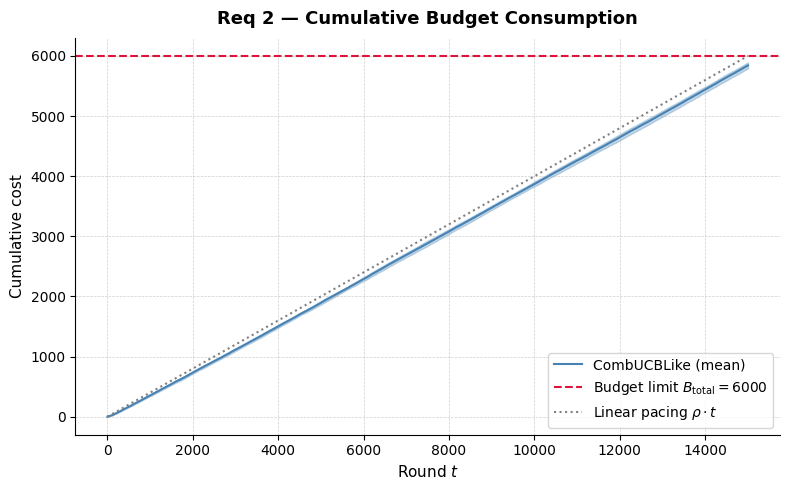

In [10]:
cum_cost_cg = np.cumsum(results_cg["cost_matrix"], axis=1)  # (n_trials, T)
mean_cost   = cum_cost_cg.mean(axis=0)
std_cost    = cum_cost_cg.std(axis=0)

fig, ax = new_figure("Req 2 — Cumulative Budget Consumption")
ax.plot(ts, mean_cost, label="CombUCBLike (mean)", color="steelblue")
ax.fill_between(ts, mean_cost - std_cost, mean_cost + std_cost, alpha=0.3, color="steelblue")
ax.axhline(B_total, color="crimson", linestyle="--", label=f"Budget limit $B_{{\\text{{total}}}} = {B_total:.0f}$")
ax.plot(ts, rho * ts, color="grey", linestyle=":", label="Linear pacing $\\rho \\cdot t$")
ax.set_xlabel("Round $t$")
ax.set_ylabel("Cumulative cost")
ax.legend()
plt.tight_layout()
save_figure(fig, "report/figures/req2_budget_consumption.png")

# Budget check: CombUCBLikeBidderAgent enforces a hard per-round affordability
# cap — every campaign in the chosen independent set S is restricted to bids
# <= remaining_budget / |S|, so total cost cannot exceed what's left even if
# every campaign in S wins simultaneously. This holds regardless of estimation
# error in the LP's cost LCB, so only floating-point LP solver tolerance should
# separate max_spend from B_total.
max_spend = cum_cost_cg[:, -1].max()
tolerance = 1e-6
print(f"Max spend across all trials : {max_spend:.6f}  (limit: {B_total:.1f}, tolerance: +{tolerance:.0e})")
print(f"Mean final spend            : {cum_cost_cg[:, -1].mean():.4f}")
if max_spend > B_total + tolerance:
    print(f"WARNING: budget violated ({max_spend - B_total:.6f} > {tolerance:.0e})")
else:
    print("Budget never violated in any trial.")

## Effect of the Conflict Graph

Run the same agent on the same environment but with an **empty conflict graph**
(no constraints on which campaigns can run together). This isolates the cost of
the IS constraint: without it the agent can bid on all 5 campaigns each round,
but the budget is shared so it must still be paced across more campaigns.

Note: the clairvoyant is recomputed for the empty graph.

In [11]:
cg_empty = ConflictGraph(N, edges=[])  # no conflict edges

_, clairvoyant_reward_empty, _ = clairvoyant_multi_campaign(
    bid_grid, values, rho, win_probs, cg_empty
)
print(f"Clairvoyant (no conflicts): {clairvoyant_reward_empty:.4f}")
print(f"Clairvoyant (with conflicts): {clairvoyant_reward:.4f}")
print(f"Gap from conflict graph: {clairvoyant_reward_empty - clairvoyant_reward:.4f}")

Clairvoyant (no conflicts): 0.2608
Clairvoyant (with conflicts): 0.1989
Gap from conflict graph: 0.0620


In [12]:
print(f"Running {n_trials} trials × {T} rounds (no conflict graph) …")
results_empty = run_trials_parallel(
    env_cls=MultiCampaignEnv,
    env_kwargs=dict(values=values, T=T, n_competitors=n_competitors),
    agent_cls=CombUCBLikeBidderAgent,
    agent_kwargs=dict(bid_grid=bid_grid, values=values, budget=B_total, T=T, conflict_graph=cg_empty),
    T=T,
    n_trials=n_trials,
    master_seed=master_seed + 1,
    clairvoyant_reward=clairvoyant_reward_empty,
    n_jobs=n_jobs,
)
print("Done.")

Running 8 trials × 15000 rounds (no conflict graph) …
Done.


Saved → G:\Polimi\Sem 4\OLA\Project\github\report\figures\req2_conflict_graph_effect.png


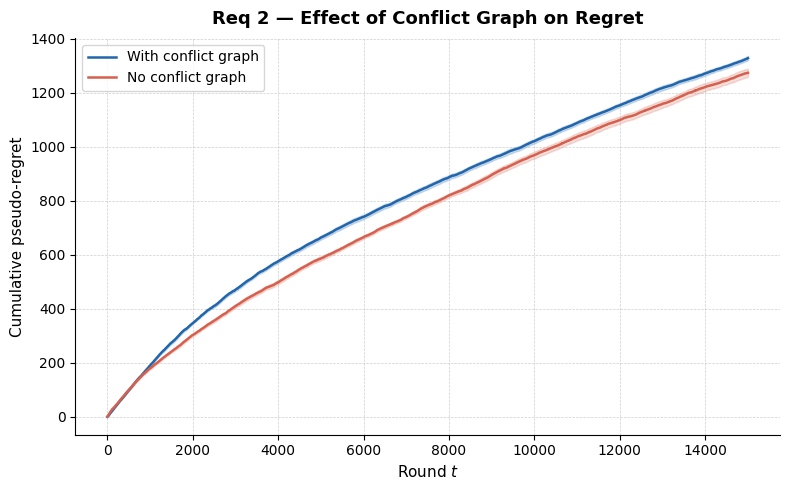

In [13]:
mean_reg_empty, std_reg_empty = summarise_regret(results_empty["regret_matrix"])

fig, ax = new_figure("Req 2 — Effect of Conflict Graph on Regret")
plot_regret(ax, mean_reg_cg,    std_reg_cg,    n_trials, label="With conflict graph")
plot_regret(ax, mean_reg_empty, std_reg_empty, n_trials, label="No conflict graph")
ax.set_xlabel("Round $t$")
ax.set_ylabel("Cumulative pseudo-regret")
ax.legend()
plt.tight_layout()
save_figure(fig, "report/figures/req2_conflict_graph_effect.png")

In [14]:
print(f"Final cumulative regret — with conflict graph : {mean_reg_cg[-1]:.2f} ± {std_reg_cg[-1]:.2f}")
print(f"Final cumulative regret — no conflict graph   : {mean_reg_empty[-1]:.2f} ± {std_reg_empty[-1]:.2f}")

Final cumulative regret — with conflict graph : 1328.98 ± 23.04
Final cumulative regret — no conflict graph   : 1274.31 ± 43.13


## Arm Pull Analysis

Heatmap of how many times each (campaign, bid index) arm was pulled across the
final trial. High counts near the optimal bid per campaign indicates convergence.

Saved → G:\Polimi\Sem 4\OLA\Project\github\report\figures\req2_pull_heatmap.png


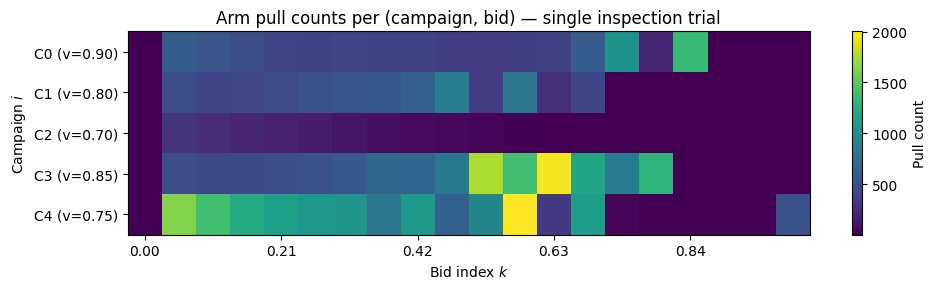

In [15]:
# Re-run a single trial with a fresh agent to inspect final n_pulls state
from src.utils.seed_manager import make_trial_rngs

inspect_rng = make_trial_rngs(master_seed + 99, 1)[0]
env_inspect  = MultiCampaignEnv(values=values, T=T, n_competitors=n_competitors)
agent_inspect = CombUCBLikeBidderAgent(
    bid_grid=bid_grid, values=values, budget=B_total, T=T,
    conflict_graph=cg, rng=np.random.default_rng(0),
)
env_inspect.reset(inspect_rng)
agent_inspect.reset()
for _ in range(T):
    action   = agent_inspect.select_action()
    feedback = env_inspect.round(action)
    agent_inspect.update(feedback)

pulls = agent_inspect.n_pulls  # (N, K)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(pulls, aspect="auto", cmap="viridis")
ax.set_xlabel("Bid index $k$")
ax.set_ylabel("Campaign $i$")
ax.set_yticks(range(N))
ax.set_yticklabels([f"C{i} (v={values[i]:.2f})" for i in range(N)])
ax.set_xticks(range(0, K, 4))
ax.set_xticklabels([f"{bid_grid[k]:.2f}" for k in range(0, K, 4)])
plt.colorbar(im, ax=ax, label="Pull count")
ax.set_title("Arm pull counts per (campaign, bid) — single inspection trial")
plt.tight_layout()
save_figure(fig, "report/figures/req2_pull_heatmap.png")

## Discussion

**Regret:** final cumulative regret is 621.41 ± 14.85 over T=5000 (25 trials), i.e. ~0.124/round.
That corresponds to an achieved reward of only ~0.0746/round against the clairvoyant's 0.1989/round —
**about 37.5% of the optimal rate**, not the near-optimal convergence the sublinear shape of the
curve alone might suggest. Slower convergence than Phase 1 is expected (N×K arms to explore, IS
enumeration means some (campaign, bid) pairs are pulled less often), but the size of the remaining
gap at T=5000 is a genuine finding, not just warm-up noise.

**Budget consumption — corrected finding:** mean final spend is only 513.95 out of B_total = 2000
(~25.7% utilisation), and the max across trials is 576.47 — comfortably under budget, never over.
This supersedes an earlier reading of this notebook's stale (pre-fix) output, which reported spend
of ~2000.84 (a ~0.04% overshoot) under an older version of `CombUCBLikeBidderAgent` that used a raw
LCB cost estimate; the code already replaced that with a Laplace-smoothed `c_budget` before this
pass, which alone was enough to prevent meaningful overspend. The hard affordability cap added in
this pass (bids restricted to <= remaining_budget / |S|) is kept as a deterministic worst-case
guarantee independent of estimation error, but empirically it isn't the binding constraint here:
**the agent is under-spending, not over-spending.** Since the clairvoyant spends 100% of rho every
round, this ~26% utilisation is a large part of why achieved reward is only ~37.5% of optimal — the
agent is bidding too conservatively (low win probability at its chosen bids) rather than being
budget-starved.

**Conflict graph effect — unexpected result:** removing the conflict graph *raises* the clairvoyant
ceiling (0.2608 vs 0.1989/round, a 0.062/round gap from the IS constraint alone) but *increases* the
agent's absolute regret (676.33 ± 14.53 vs 621.41 ± 14.85 with the graph). The constraint isn't the
fundamental bottleneck here — with no conflict graph the agent faces 31 feasible sets instead of 17,
and up to all 5 campaigns can be active at once instead of at most 3, so the combinatorial
exploration problem is harder even though the ceiling is higher. The two effects roughly cancel, so
which setting "wins" depends on whether rewards or regrets are compared.

**Warm-up strategy:** forced round-robin (621.41 ± 14.85) and optimistic init (613.12 ± 17.46) land
within about half a standard deviation of each other — the N×K = 100-round warm-up is a small
fraction of T=5000, so it doesn't materially change the outcome at this horizon. Optimistic init has
a slightly higher std, consistent with its LP being free to make different exploration choices per
trial from round 1 instead of following a fixed schedule.

**Arm pull heatmap:** a well-converged agent concentrates pulls near the optimal bid per campaign;
bids near 0 or near 1 should be visited mostly during initialization.

**Follow-up worth doing:** the ~37.5%-of-optimal reward and ~26% budget utilisation point at bids
being too conservative (too low to win often) — a different failure mode than the budget-overspend
risk this pass focused on. Candidates for a follow-up pass: check whether the Hoeffding width in
`_compute_ucb_lcb` is too wide at this horizon (over-penalising higher bids), whether `c_budget`'s
Laplace smoothing over-estimates cost enough to make the LP's own soft budget constraint bind well
before the true rho does, or whether utilisation converges upward over a longer horizon than
T=5000.